# **Analysing Messy Dataset**

This Notebook perform following actions on given dataset


*   Remove duplicates
*   List item



In [23]:
!pip install pandas matplotlib seaborn word2number

# Import libraries
import pandas as pd
import seaborn as sns
import glob
import matplotlib.pyplot as plt
from word2number import w2n
import numpy as np
from scipy import stats
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler

# Upload the CSV file

In [2]:
from google.colab import files
uploaded = files.upload()

Saving messy_dataset.csv to messy_dataset.csv


# Load the dataset using pandas and verify

In [3]:
df = pd.read_csv("messy_dataset.csv")
print(df.head())

    ID     Name           Age Country Salary   Join Date
0  1.0    Alice            25      NZ  55000  15/01/2020
1  2.0      Bob           NaN      NZ  60000  20/02/2020
2  2.0      Bob            30      NZ    NaN  20/02/2020
3  4.0  Charlie            35     AUS  72000         NaN
4  5.0    David  thirty-eight      NZ  68000   1/11/2019


Check for duplicated data
Remove fully duplicated data
Merge semi duplicated

In [4]:
# ── STEP 1: CHECK FULLY DUPLICATE ROWS ────────────────────────
print("\n" + "=" * 55)
print("STEP 1: FULLY DUPLICATE ROWS")
print("=" * 55)
full_dups = df[df.duplicated(keep=False)]
if full_dups.empty:
    print("No fully duplicate rows found.")
else:
    print(full_dups.to_string())

# ── STEP 2: CHECK DUPLICATE BY 'ID' COLUMN ────────────────
print("\n" + "=" * 55)
print("STEP 2: DUPLICATE IDs (same person, different data)")
print("=" * 55)
dup_id_rows = df[df.duplicated(subset=['ID'], keep=False) & df['ID'].notna()]
if dup_id_rows.empty:
    print("No duplicate IDs found.")
else:
    print(dup_id_rows.to_string())

    # ── STEP 3: FIX — MERGE DUPLICATE ID ROWS ─────────────────────
    print("\n" + "=" * 55)
    print("STEP 3: MERGING DUPLICATE ID ROWS")
    print("=" * 55)
    before = len(df)
    dup_ids = df[df.duplicated(subset=['ID'], keep=False) & df['ID'].notna()]['ID'].unique()

    for dup_id in dup_ids:
        dup_rows = df[df['ID'] == dup_id]
        print(f"\nMerging rows with ID = {dup_id}:")
        print(dup_rows.to_string())
        merged = dup_rows.ffill().bfill().iloc[0]
        df = df[df['ID'] != dup_id]
        df = pd.concat([df, merged.to_frame().T], ignore_index=True)
        print(f"\n→ Merged result:")
        print(merged.to_frame().T.to_string())
    after = len(df)
    print(f"Removed {before - after} fully duplicate row(s).")
    # ── STEP 5: SORT & RESET INDEX ─────────────────────────────────
    df = df.sort_values('ID').reset_index(drop=True)


STEP 1: FULLY DUPLICATE ROWS
No fully duplicate rows found.

STEP 2: DUPLICATE IDs (same person, different data)
    ID Name  Age Country Salary   Join Date
1  2.0  Bob  NaN      NZ  60000  20/02/2020
2  2.0  Bob   30      NZ    NaN  20/02/2020

STEP 3: MERGING DUPLICATE ID ROWS

Merging rows with ID = 2.0:
    ID Name  Age Country Salary   Join Date
1  2.0  Bob  NaN      NZ  60000  20/02/2020
2  2.0  Bob   30      NZ    NaN  20/02/2020

→ Merged result:
    ID Name Age Country Salary   Join Date
1  2.0  Bob  30      NZ  60000  20/02/2020
Removed 1 fully duplicate row(s).


# **Handle Null Values**

In [5]:
# ── STEP 1: DETECT text in numeric columns ─────────────────────
print("=" * 55)
print("DETECTING TEXT IN NUMERIC COLUMNS")
print("=" * 55)
for col in ['Age', 'Salary']:
    converted = pd.to_numeric(df[col], errors='coerce')
    bad = df[converted.isna() & df[col].notna()]
    if not bad.empty:
        print(f"\n'{col}' has non-numeric values:")
        print(bad[['ID', 'Name', col]].to_string())


DETECTING TEXT IN NUMERIC COLUMNS

'Age' has non-numeric values:
    ID   Name           Age
3  5.0  David  thirty-eight

'Salary' has non-numeric values:
    ID Name               Salary
4  7.0  NaN  sixty five thousand


In [6]:
def words_to_number(text):
    """Convert written number text to integer value."""
    if pd.isna(text):
        return text
    try:
        text = str(text).lower().strip()
        text = text.replace('-', ' ')
        print(text)
        return float(w2n.word_to_num(text))           # already numeric — return as-is
    except (ValueError, TypeError):
        pass
    return None

In [7]:
# ── STEP 3: APPLY CONVERSION ───────────────────────────────────
print("\n" + "=" * 55)
print("APPLYING CONVERSION")
print("=" * 55)
for col in ['Age', 'Salary']:
    df[col] = df[col].apply(words_to_number)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f"'{col}' → converted to {df[col].dtype}")

# ── FINAL RESULT ───────────────────────────────────────────────
print("\n" + "=" * 55)
print("AFTER FIX")
print("=" * 55)
print(df[['ID', 'Name', 'Age', 'Salary']].to_string())


APPLYING CONVERSION
25
30
35
thirty eight
40
22
27
29
'Age' → converted to float64
55000
60000
72000
68000
sixty five thousand
64000
58000
59000
'Salary' → converted to float64

AFTER FIX
     ID     Name   Age   Salary
0   1.0    Alice  25.0  55000.0
1   2.0      Bob  30.0  60000.0
2   4.0  Charlie  35.0  72000.0
3   5.0    David  38.0  68000.0
4   7.0      NaN  40.0  65000.0
5   8.0    Grace  22.0  64000.0
6   9.0    Heidi   NaN      NaN
7  10.0     Ivan  27.0  58000.0
8   NaN      Eve  29.0  59000.0


# **CHECK for NULL Values**

In [8]:
print("NULLS BEFORE FIX:")
print(df.isnull().sum())

# ── FIX 1: ID — assign next available number ───────────────────
next_id = int(df['ID'].max()) + 1
df['ID'] = df['ID'].fillna(next_id)

# ── FIX 2: Name — unknown text value ───────────────────────────
df['Name'] = df['Name'].fillna('Unknown')

# ── FIX 3: Age — fill with median ──────────────────────────────
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

# ── FIX 4: Country — unknown text value ────────────────────────
df['Country'] = df['Country'].fillna('Unknown')

# ── FIX 5: Salary — fill with median ───────────────────────────
median_salary = df['Salary'].median()
df['Salary'] = df['Salary'].fillna(median_salary)

# ── FIX 6: Join Date — unknown text value ──────────────────────
df['Join Date'] = df['Join Date'].fillna('Unknown')

print("\nNULLS AFTER FIX:")
print(df.isnull().sum())

print("\nCLEANED DATA:")
print(df.to_string())

NULLS BEFORE FIX:
ID           1
Name         1
Age          1
Country      1
Salary       1
Join Date    1
dtype: int64

NULLS AFTER FIX:
ID           0
Name         0
Age          0
Country      0
Salary       0
Join Date    0
dtype: int64

CLEANED DATA:
     ID     Name   Age  Country   Salary   Join Date
0   1.0    Alice  25.0       NZ  55000.0  15/01/2020
1   2.0      Bob  30.0       NZ  60000.0  20/02/2020
2   4.0  Charlie  35.0      AUS  72000.0     Unknown
3   5.0    David  38.0       NZ  68000.0   1/11/2019
4   7.0  Unknown  40.0       NZ  65000.0  30/05/2018
5   8.0    Grace  22.0  Unknown  64000.0  25/07/2021
6   9.0    Heidi  29.5      AUS  62000.0  25/07/2021
7  10.0     Ivan  27.0       NZ  58000.0  15/03/2019
8  11.0      Eve  29.0       AU  59000.0  2019-13-01


/tmp/ipykernel_8954/587509964.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['ID'] = df['ID'].fillna(next_id)


# **Fixing Inconsistent Data types**

In [9]:
# ── FIX 1: Invalid Date Format — CONVERT TO DD/MM/YYYY Format ───────────────────
# Define the general function for the date conversion
def fix_date(x):
    try:
        # First try normal parsing
        return pd.to_datetime(x, dayfirst=True)
    except:
        try:
            # Handle wrong format like "2019-13-01"
            parts = str(x).split("-")
            if len(parts) == 3:
                year, day, month = parts
                return pd.to_datetime(f"{day}/{month}/{year}", dayfirst=True)
        except:
            return pd.NaT

print("\n" + "=" * 55)
print("FIXING INVALID DATE FORMAT")
print("=" * 55)
df["Join Date"] = df["Join Date"].apply(fix_date)
# ── STEP 4: Restore any NaT back to 'Unknown' ──────────────────
df["Join Date"] = df["Join Date"].fillna("Unknown")

# ── FIX 2: Invalid Country CODE — CONVERT AU TO AUS ───────────────────
print("\n" + "=" * 55)
print("FIXING INCONSISTANT COUNTRY CODES")
print("=" * 55)
df["Country"] = df["Country"].replace({"AU": "AUS"})

# ── FIX 3: Data type conversion for ID Column - Convert Float to Int ───────────────────
df["ID"] = df["ID"].astype("Int64")

print("\nCLEANED DATA:")
print(df.to_string())


FIXING INVALID DATE FORMAT

FIXING INCONSISTANT COUNTRY CODES

CLEANED DATA:
   ID     Name   Age  Country   Salary            Join Date
0   1    Alice  25.0       NZ  55000.0  2020-01-15 00:00:00
1   2      Bob  30.0       NZ  60000.0  2020-02-20 00:00:00
2   4  Charlie  35.0      AUS  72000.0              Unknown
3   5    David  38.0       NZ  68000.0  2019-11-01 00:00:00
4   7  Unknown  40.0       NZ  65000.0  2018-05-30 00:00:00
5   8    Grace  22.0  Unknown  64000.0  2021-07-25 00:00:00
6   9    Heidi  29.5      AUS  62000.0  2021-07-25 00:00:00
7  10     Ivan  27.0       NZ  58000.0  2019-03-15 00:00:00
8  11      Eve  29.0      AUS  59000.0  2019-01-13 00:00:00


# **VISUALIZATION OF DATA**
**Salary Distribution (Histogram)**

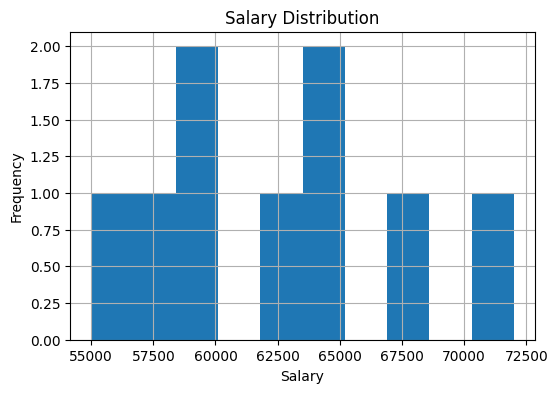

In [10]:
plt.figure(figsize=(6,4))
df["Salary"].hist(bins=10)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

Salary by Country

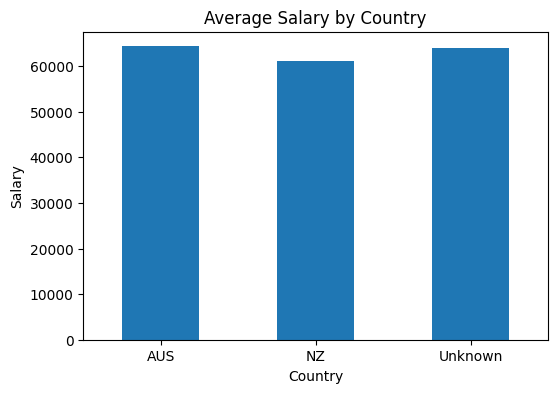

In [11]:
avg_salary = df.groupby("Country")["Salary"].mean()

avg_salary.plot(kind="bar", figsize=(6,4))

plt.title("Average Salary by Country")
plt.ylabel("Salary")
plt.xticks(rotation=0)
plt.show()

Age vs Salary (Scatter Plot)

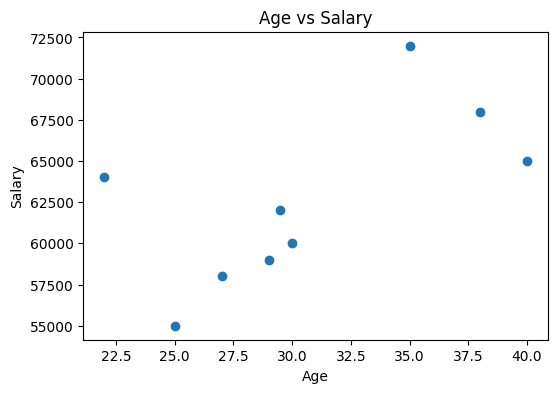

In [12]:
plt.figure(figsize=(6,4))

plt.scatter(df["Age"], df["Salary"])

plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

Country Distribution (Pie Chart)

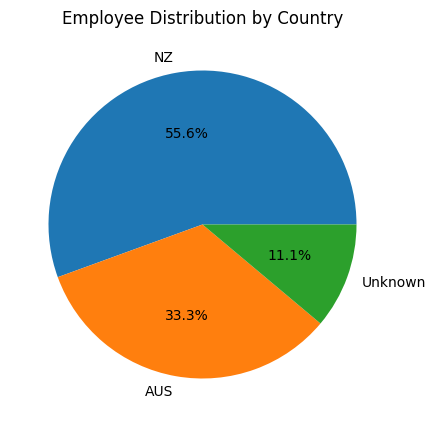

In [13]:
df["Country"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(5,5)
)

plt.title("Employee Distribution by Country")
plt.ylabel("")
plt.show()

# **Correlation Heatmap**

Pearson r matrix:
           Age  Salary
Age     1.0000  0.6289
Salary  0.6289  1.0000

P-value matrix:
           Age  Salary
Age     0.0000  0.0696
Salary  0.0696  0.0000

Saved as plot5_scipy_heatmap.png


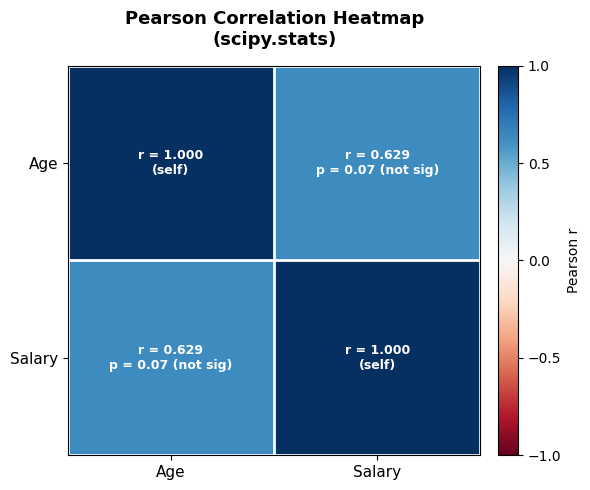

In [18]:
# ══════════════════════════════════════════════════════════
# STEP 2: SELECT ONLY NUMERIC FEATURE COLUMNS
# ══════════════════════════════════════════════════════════

# Pearson correlation only works on numeric (number) columns
# We exclude "ID" because it is just a row label (1, 2, 3...)
# and has no real meaning as a feature — it would give misleading results
numeric_df = df[["Age", "Salary"]]

# Get the column names as a list → ["Age", "Salary"]
cols = numeric_df.columns

# Count how many columns we have → n = 2
n = len(cols)

# ══════════════════════════════════════════════════════════
# STEP 3: BUILD EMPTY MATRICES TO STORE r AND p VALUES
# ══════════════════════════════════════════════════════════

# scipy.stats.pearsonr() computes correlation for ONE PAIR at a time
# So we need to loop through every column pair and store results

# r_matrix: stores the Pearson r value for each pair
# Start filled with 1.0 because every column perfectly correlates with itself
r_matrix = pd.DataFrame(
    np.ones((n, n)),   # n x n matrix filled with 1.0
    columns=cols,      # column names = ["Age", "Salary"]
    index=cols         # row names    = ["Age", "Salary"]
)

# p_matrix: stores the p-value for each pair
# Start filled with 0.0 (diagonal = self correlation, p-value not applicable)
p_matrix = pd.DataFrame(
    np.zeros((n, n)),  # n x n matrix filled with 0.0
    columns=cols,
    index=cols
)

# ══════════════════════════════════════════════════════════
# STEP 4: COMPUTE PEARSON r AND p-VALUE FOR EVERY PAIR
# ══════════════════════════════════════════════════════════

# Loop through every row-column combination in the matrix
for i in range(n):        # i = row index (0=Age, 1=Salary)
    for j in range(n):    # j = column index (0=Age, 1=Salary)

        # Skip diagonal cells (e.g. Age vs Age = always 1.0, no need to compute)
        if i != j:

            # stats.pearsonr() returns TWO values:
            #   r_val   → the correlation coefficient (-1 to +1)
            #   p_val   → the p-value (measures statistical significance)
            r_val, p_val = stats.pearsonr(
                numeric_df.iloc[:, i],   # all rows of column i
                numeric_df.iloc[:, j]    # all rows of column j
            )

            # Store r value in the r_matrix at position [i, j]
            r_matrix.iloc[i, j] = r_val

            # Store p value in the p_matrix at position [i, j]
            p_matrix.iloc[i, j] = p_val

# Print results to console for reference
print("Pearson r matrix:")
print(r_matrix.round(4))
print("\nP-value matrix:")
print(p_matrix.round(4))

# ══════════════════════════════════════════════════════════
# STEP 5: CREATE THE HEATMAP FIGURE
# ══════════════════════════════════════════════════════════

# Create a figure and axes with size 6x5 inches
fig, ax = plt.subplots(figsize=(6, 5))

# Choose colour map: RdBu = Red → White → Blue
#   Red   = strong negative correlation (r close to -1)
#   White = no correlation             (r close to  0)
#   Blue  = strong positive correlation (r close to +1)
cmap = plt.cm.RdBu

# Draw the heatmap using imshow()
# r_matrix values control the cell colour
# vmin=-1 and vmax=1 fix the colour scale so 0 is always white
im = ax.imshow(r_matrix, cmap=cmap, vmin=-1, vmax=1, aspect="auto")

# ══════════════════════════════════════════════════════════
# STEP 6: ADD COLOUR BAR (LEGEND ON THE SIDE)
# ══════════════════════════════════════════════════════════

# Add a colourbar on the right side to explain what each colour means
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Label the colourbar
cbar.set_label("Pearson r", fontsize=10)

# Set tick marks at key positions on the colour scale
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

# ══════════════════════════════════════════════════════════
# STEP 7: SET AXIS LABELS (ROW AND COLUMN NAMES)
# ══════════════════════════════════════════════════════════

# Set x-axis tick positions (one per column)
ax.set_xticks(range(n))

# Set y-axis tick positions (one per row)
ax.set_yticks(range(n))

# Label x-axis ticks with column names → "Age", "Salary"
ax.set_xticklabels(list(cols), fontsize=11)

# Label y-axis ticks with column names → "Age", "Salary"
ax.set_yticklabels(list(cols), fontsize=11)

# ══════════════════════════════════════════════════════════
# STEP 8: ANNOTATE EACH CELL WITH r VALUE AND p-VALUE
# ══════════════════════════════════════════════════════════

# Loop through every cell in the matrix to write text inside it
for i in range(n):
    for j in range(n):

        # Get the r value and p-value for this cell
        r_val = r_matrix.iloc[i, j]
        p_val = p_matrix.iloc[i, j]

        # Get the absolute r value to decide text colour
        abs_val = abs(r_val)

        # Use white text on dark (high correlation) cells for readability
        # Use black text on light (low correlation) cells
        text_color = "white" if abs_val > 0.6 else "black"

        # Diagonal cells = self correlation (Age vs Age, Salary vs Salary)
        if i == j:
            label = "r = 1.000\n(self)"   # always 1, label it clearly

        else:
            # Check if p-value is statistically significant
            # p < 0.05 → result is significant (less than 5% chance it's random)
            # p >= 0.05 → result is NOT significant (could be due to chance)
            sig = "p < 0.05 (sig)" if p_val < 0.05 else f"p = {p_val:.2f} (not sig)"

            # Combine r value and significance into the cell label
            label = f"r = {r_val:.3f}\n{sig}"

        # Write the label text in the centre of the cell
        ax.text(
            j, i,          # x=j (column), y=i (row) position
            label,         # text to display
            ha="center",   # horizontal alignment
            va="center",   # vertical alignment
            fontsize=9,
            fontweight="bold",
            color=text_color
        )

# ══════════════════════════════════════════════════════════
# STEP 9: ADD GRID LINES BETWEEN CELLS
# ══════════════════════════════════════════════════════════

# Draw white horizontal and vertical lines to separate cells cleanly
# np.arange(-0.5, n, 1) gives positions halfway between cells
for x in np.arange(-0.5, n, 1):
    ax.axhline(x, color="white", linewidth=2)  # horizontal line
    ax.axvline(x, color="white", linewidth=2)  # vertical line

# ══════════════════════════════════════════════════════════
# STEP 10: TITLE, SAVE AND SHOW
# ══════════════════════════════════════════════════════════

# Add a descriptive title
ax.set_title(
    "Pearson Correlation Heatmap\n(scipy.stats)",
    fontsize=13,
    fontweight="bold",
    pad=15   # space between title and plot
)

# Adjust layout so nothing gets clipped
plt.tight_layout()

# Save the plot as a PNG image file
plt.savefig("plot5_scipy_heatmap.png", dpi=150, bbox_inches="tight")
print("\nSaved as plot5_scipy_heatmap.png")

# Display the plot on screen
plt.show()

# **BoxPlot - To detect outliers**

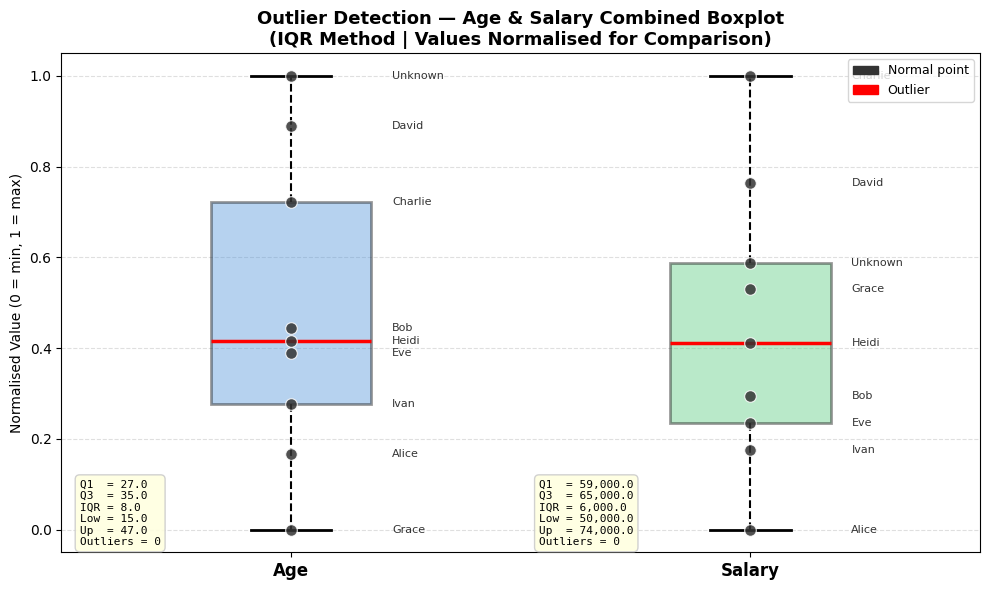

In [24]:
# ══════════════════════════════════════════════════════════
# STEP 2: NORMALISE BOTH COLUMNS TO 0-1 SCALE
# ══════════════════════════════════════════════════════════

# Age ranges from ~22 to 40
# Salary ranges from ~55000 to 72000
# These are completely different scales — we can't plot them
# on the same y-axis without normalising first

# MinMaxScaler converts every value to a 0-1 range:
#   0 = the minimum value in that column
#   1 = the maximum value in that column
scaler    = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df[["Age", "Salary"]]),
    columns=["Age", "Salary"]
)

# ══════════════════════════════════════════════════════════
# STEP 3: CREATE SINGLE FIGURE WITH BOTH BOXPLOTS
# ══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 6))

cols      = ["Age", "Salary"]
colors    = ["#4A90D9", "#50C878"]   # blue for Age, green for Salary
positions = [1, 2]                   # x positions for the two boxes

# ══════════════════════════════════════════════════════════
# STEP 4: LOOP AND DRAW EACH BOXPLOT ON THE SAME AXES
# ══════════════════════════════════════════════════════════

for idx, (col, color, pos) in enumerate(zip(cols, colors, positions)):

    original = df[col]        # original values — used for IQR calculation
    scaled   = df_scaled[col] # scaled values — used for plotting

    # ── COMPUTE IQR ON ORIGINAL VALUES ────────────────────
    # Always compute IQR on original values — not scaled
    # so the fence numbers in the stats box are readable
    Q1    = original.quantile(0.25)   # 25th percentile
    Q3    = original.quantile(0.75)   # 75th percentile
    IQR   = Q3 - Q1                   # interquartile range
    lower = Q1 - 1.5 * IQR           # lower outlier fence
    upper = Q3 + 1.5 * IQR           # upper outlier fence

    # ── DRAW BOXPLOT USING SCALED VALUES ──────────────────
    # positions=[pos] places the box at x=1 or x=2
    bp = ax.boxplot(
        scaled,
        positions=[pos],
        vert=True,
        patch_artist=True,      # allows colouring the box
        widths=0.35,
        boxprops=dict(facecolor=color, alpha=0.4, linewidth=2),
        medianprops=dict(color="red", linewidth=2.5),
        whiskerprops=dict(linewidth=1.5, linestyle="--"),
        capprops=dict(linewidth=2),
        flierprops=dict(marker="o", color="red",
                        markerfacecolor="red", markersize=10)
    )

    # ── PLOT EMPLOYEE DOTS + NAME LABELS ──────────────────
    for _, row in df.iterrows():
        val = row[col]

        # Manually normalise the value to match the scaled plot
        scaled_val = (val - original.min()) / (original.max() - original.min())

        # Check if this employee is an outlier using original values
        is_outlier = val < lower or val > upper
        dot_color  = "red" if is_outlier else "#333"

        # Plot dot at the scaled value position
        ax.scatter(pos, scaled_val, color=dot_color, s=70, zorder=5,
                   alpha=0.85, edgecolors="white", linewidth=0.8)

        # Add name label slightly to the right of the dot
        ax.annotate(
            row["Name"],
            xy=(pos, scaled_val),
            xytext=(pos + 0.22, scaled_val),  # offset right by 0.22 units
            fontsize=8,
            color=dot_color,
            fontweight="bold" if is_outlier else "normal",
            va="center"
        )

    # ── IQR STATS BOX ─────────────────────────────────────
    outliers  = df[(original < lower) | (original > upper)]
    stats_text = (
        f"Q1  = {Q1:,.1f}\n"
        f"Q3  = {Q3:,.1f}\n"
        f"IQR = {IQR:,.1f}\n"
        f"Low = {lower:,.1f}\n"
        f"Up  = {upper:,.1f}\n"
        f"Outliers = {len(outliers)}"
    )
    # Place stats box at bottom-left for Age, bottom-centre for Salary
    x_offset = 0.02 if idx == 0 else 0.52
    ax.text(
        x_offset, 0.01, stats_text,
        transform=ax.transAxes,    # use relative (0-1) axis coordinates
        fontsize=8, va="bottom", ha="left",
        fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow",
                  edgecolor="#ccc", alpha=0.9)
    )

# ══════════════════════════════════════════════════════════
# STEP 5: FORMATTING, LEGEND, SAVE
# ══════════════════════════════════════════════════════════

# Set x-axis labels to column names at positions 1 and 2
ax.set_xticks(positions)
ax.set_xticklabels(["Age", "Salary"], fontsize=12, fontweight="bold")

# Y-axis label explains the normalised scale
ax.set_ylabel("Normalised Value (0 = min, 1 = max)", fontsize=10)

ax.set_title(
    "Outlier Detection — Age & Salary Combined Boxplot\n"
    "(IQR Method | Values Normalised for Comparison)",
    fontsize=13, fontweight="bold"
)

# Legend: normal vs outlier dot colour
normal_patch  = mpatches.Patch(color="#333", label="Normal point")
outlier_patch = mpatches.Patch(color="red",  label="Outlier")
ax.legend(handles=[normal_patch, outlier_patch], fontsize=9, loc="upper right")

# Light horizontal grid lines for readability
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()